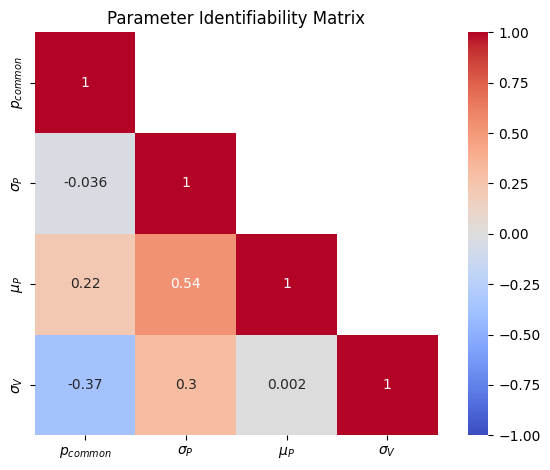

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bci_df = pd.read_csv('csv/modeling/outputs/free_mup/sigma_a_p2/bci_best_models.csv')
df = bci_df[bci_df['location'] == 'visible'].copy()

parameter_order = ['pcommon', 'sigma_p', 'mu_p', 'sigma_v']
parameter_labels = {
    'pcommon': r'$p_{common}$',
    'sigma_p': r'$\sigma_P$',
    'mu_p': r'$\mu_P$',
    'sigma_v': r'$\sigma_V$',
}

corr_matrix = df[parameter_order].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=[parameter_labels[p] for p in parameter_order],
    yticklabels=[parameter_labels[p] for p in parameter_order],
)
ax.set_title('Parameter Identifiability Matrix')
plt.tight_layout()
plt.savefig('../plots/figure_s4.png', dpi=300, bbox_inches='tight')
plt.show()